# Libraries

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)


# Load Data

In [47]:
# Load the data directly from GitHub
data_url = "https://raw.githubusercontent.com/mendible/5322/main/Homework%202/nhis_2022.csv"
nhis_raw = pd.read_csv(data_url)

# Data Cleaning

In [48]:
# Inspect data
df = nhis_raw.copy()

# 1. Basic dataset size
print("Dataset shape:")
print(df.shape)

# 2. Column names
print("Column names:")
print(df.columns.tolist())

# 3. Data types
print("Data types:")
print(df.dtypes)

# 4. Preview the first few rows
display(df.head())

# 5. Check missing values coded as actual NaN
print("Number of actual NaN values by column:")
print(df.isna().sum().sort_values(ascending=False))

# 6. Check the target variable distribution before cleaning
print("Raw DIABETICEV value counts:")
print(df["DIABETICEV"].value_counts(dropna=False).sort_index())

# 7. Check key predictor variables before cleaning
key_vars = [
    "AGE", "SEX", "EDUC", "POVERTY", "BMICALC",
    "HOURSWRK", "MOD10DMIN", "VIG10DMIN",
    "HRSLEEP", "SODAPNO", "FRUTNO", "VEGENO",
    "DIABETICEV"
]

Dataset shape:
(35115, 48)
Column names:
['YEAR', 'SERIAL', 'STRATA', 'PSU', 'NHISHID', 'REGION', 'PERNUM', 'NHISPID', 'HHX', 'SAMPWEIGHT', 'ASTATFLG', 'CSTATFLG', 'AGE', 'SEX', 'MARSTCUR', 'EDUC', 'HOURSWRK', 'POVERTY', 'HEIGHT', 'WEIGHT', 'BMICALC', 'HINOTCOVE', 'CANCEREV', 'CHEARTDIEV', 'DIABETICEV', 'HEARTATTEV', 'STROKEV', 'ALCANYNO', 'ALCDAYSYR', 'CIGDAYMO', 'MOD10DMIN', 'VIG10DMIN', 'FRUTNO', 'VEGENO', 'JUICEMNO', 'SALADSNO', 'BEANNO', 'SALSAMNO', 'TOMSAUCEMNO', 'SODAPNO', 'FRIESPNO', 'SPORDRMNO', 'FRTDRINKMNO', 'COFETEAMNO', 'POTATONO', 'PIZZANO', 'HRSLEEP', 'CVDSHT']
Data types:
YEAR             int64
SERIAL           int64
STRATA           int64
PSU              int64
NHISHID         object
REGION           int64
PERNUM           int64
NHISPID         object
HHX             object
SAMPWEIGHT     float64
ASTATFLG         int64
CSTATFLG         int64
AGE              int64
SEX              int64
MARSTCUR         int64
EDUC             int64
HOURSWRK         int64
POVERTY       

,YEAR,SERIAL,STRATA,PSU,NHISHID,REGION,PERNUM,NHISPID,HHX,SAMPWEIGHT,...,TOMSAUCEMNO,SODAPNO,FRIESPNO,SPORDRMNO,FRTDRINKMNO,COFETEAMNO,POTATONO,PIZZANO,HRSLEEP,CVDSHT
0,2022,1,143,16,0002022H000001,4,1,0002022H00000110,H000001,8018.0,...,2,0,110,3,0,0,3,2,8,1
1,2022,2,106,53,0002022H000003,3,1,0002022H00000310,H000003,10117.0,...,1,0,1,0,0,1,1,1,6,2
2,2022,2,106,53,0002022H000003,3,2,0002022H00000320,H000003,7933.0,...,996,996,996,996,996,996,996,996,0,2
3,2022,3,134,13,0002022H000006,2,1,0002022H00000610,H000006,2681.0,...,1,1,1,0,2,0,1,1,6,2
4,2022,4,106,53,0002022H000007,3,1,0002022H00000710,H000007,10233.0,...,3,30,5,1,0,30,6,2,8,2


Number of actual NaN values by column:
YEAR           0
SERIAL         0
STRATA         0
PSU            0
NHISHID        0
REGION         0
PERNUM         0
NHISPID        0
HHX            0
SAMPWEIGHT     0
ASTATFLG       0
CSTATFLG       0
AGE            0
SEX            0
MARSTCUR       0
EDUC           0
HOURSWRK       0
POVERTY        0
HEIGHT         0
WEIGHT         0
BMICALC        0
HINOTCOVE      0
CANCEREV       0
CHEARTDIEV     0
DIABETICEV     0
HEARTATTEV     0
STROKEV        0
ALCANYNO       0
ALCDAYSYR      0
CIGDAYMO       0
MOD10DMIN      0
VIG10DMIN      0
FRUTNO         0
VEGENO         0
JUICEMNO       0
SALADSNO       0
BEANNO         0
SALSAMNO       0
TOMSAUCEMNO    0
SODAPNO        0
FRIESPNO       0
SPORDRMNO      0
FRTDRINKMNO    0
COFETEAMNO     0
POTATONO       0
PIZZANO        0
HRSLEEP        0
CVDSHT         0
dtype: int64
Raw DIABETICEV value counts:
DIABETICEV
1    32102
2     2975
7       27
9       11
Name: count, dtype: int64


In [49]:
# Select analysis variables and clean the target variables
analysis_vars = [
    "AGE",
    "SEX",
    "EDUC",
    "POVERTY",
    "BMICALC",
    "HOURSWRK",
    "MOD10DMIN",
    "VIG10DMIN",
    "HRSLEEP",
    "SODAPNO",
    "FRUTNO",
    "VEGENO",
    "DIABETICEV"
]

# Create a smaller dataset containing only the variables needed for analysis
df_model = df[analysis_vars].copy()

# Keep only valid diabetes responses
# 1 = No, 2 = Yes
df_model = df_model[df_model["DIABETICEV"].isin([1, 2])].copy()

# Recode the target variable
# 0 = no diabetes
# 1 = diabetes
df_model["diabetes"] = df_model["DIABETICEV"].map({
    1: 0,
    2: 1
})

# Drop the original raw target variable after creating the clean version
df_model = df_model.drop(columns=["DIABETICEV"])

# Check the result
print("Shape")
print(df_model.shape)
print()

print("Clean diabetes target counts")
print(df_model["diabetes"].value_counts())
print()

print("Clean diabetes target proportions")
print(df_model["diabetes"].value_counts(normalize=True).round(4))
print()

display(df_model.head())

Shape
(35077, 13)

Clean diabetes target counts
diabetes
0    32102
1     2975
Name: count, dtype: int64

Clean diabetes target proportions
diabetes
0    0.9152
1    0.0848
Name: proportion, dtype: float64



,AGE,SEX,EDUC,POVERTY,BMICALC,HOURSWRK,MOD10DMIN,VIG10DMIN,HRSLEEP,SODAPNO,FRUTNO,VEGENO,diabetes
0,61,1,201,34,38.4,45,0,0,8,0,5,15,0
1,43,1,301,37,27.3,45,20,0,6,0,1,1,0
2,12,2,0,37,18.7,0,0,0,0,996,996,996,0
3,68,1,505,31,25.0,0,60,0,6,1,3,1,0
4,73,1,201,32,24.0,0,690,0,8,30,2,4,0


In [50]:
# Replace coded missing/unknown values with real NaN

# Make a new copy to compare before vs. after cleaning
df_clean = df_model.copy()

# Replace unknown/missing codes for demographic variables

# AGE:
# 997 = Unknown/refused
# 998 = Unknown/not ascertained
# 999 = Unknown/don't know
df_clean["AGE"] = df_clean["AGE"].replace({
    997: np.nan,
    998: np.nan,
    999: np.nan
})

# SEX:
# 1 = Male
# 2 = Female
# 7 = Unknown/refused
# 8 = Unknown/not ascertained
# 9 = Unknown/don't know
df_clean["SEX"] = df_clean["SEX"].replace({
    7: np.nan,
    8: np.nan,
    9: np.nan
})

# EDUC:
# 0 = NIU / not in universe
# 997 = Unknown/refused
# 998 = Unknown/not ascertained
# 999 = Unknown/don't know
df_clean["EDUC"] = df_clean["EDUC"].replace({
    0: np.nan,
    997: np.nan,
    998: np.nan,
    999: np.nan
})

# POVERTY:
# 98 = Undefinable
# 99 = Unknown
df_clean["POVERTY"] = df_clean["POVERTY"].replace({
    98: np.nan,
    99: np.nan
})

# Replace coded missing values for health and behavior variables

# Many NHIS behavior variables use these codes:
# 996 = Not in Universe
# 997 = Unknown/refused
# 998 = Unknown/not ascertained
# 999 = Unknown/don't know

coded_missing_996_999 = {
    996: np.nan,
    997: np.nan,
    998: np.nan,
    999: np.nan
}

behavior_vars = [
    "BMICALC",
    "HOURSWRK",
    "MOD10DMIN",
    "VIG10DMIN",
    "HRSLEEP",
    "SODAPNO",
    "FRUTNO",
    "VEGENO"
]

for col in behavior_vars:
    df_clean[col] = df_clean[col].replace(coded_missing_996_999)

# 3. Check missingness after converting coded values to NaN

print("Shape")
print(df_clean.shape)
print()

print("Missing values by column")
missing_summary = df_clean.isna().sum().sort_values(ascending=False)
print(missing_summary)
print()

print("Missing value percentages")
missing_percent = (df_clean.isna().mean() * 100).sort_values(ascending=False).round(2)
print(missing_percent)
print()

# Preview cleaned data
display(df_clean.head())

# Summary statistics after converting coded missing values
display(df_clean.describe().T)

Shape
(35077, 13)

Missing values by column
VEGENO       8592
FRUTNO       8543
SODAPNO      8508
EDUC         7605
BMICALC      6820
MOD10DMIN      88
AGE            61
VIG10DMIN      45
SEX             6
POVERTY         0
HOURSWRK        0
HRSLEEP         0
diabetes        0
dtype: int64

Missing value percentages
VEGENO       24.49
FRUTNO       24.35
SODAPNO      24.26
EDUC         21.68
BMICALC      19.44
MOD10DMIN     0.25
AGE           0.17
VIG10DMIN     0.13
SEX           0.02
POVERTY       0.00
HOURSWRK      0.00
HRSLEEP       0.00
diabetes      0.00
dtype: float64



,AGE,SEX,EDUC,POVERTY,BMICALC,HOURSWRK,MOD10DMIN,VIG10DMIN,HRSLEEP,SODAPNO,FRUTNO,VEGENO,diabetes
0,61.0,1.0,201.0,34,38.4,45,0.0,0.0,8,0.0,5.0,15.0,0
1,43.0,1.0,301.0,37,27.3,45,20.0,0.0,6,0.0,1.0,1.0,0
2,12.0,2.0,NaN,37,18.7,0,0.0,0.0,0,NaN,NaN,NaN,0
3,68.0,1.0,505.0,31,25.0,0,60.0,0.0,6,1.0,3.0,1.0,0
4,73.0,1.0,201.0,32,24.0,0,690.0,0.0,8,30.0,2.0,4.0,0


,count,mean,std,min,25%,50%,75%,max
AGE,35016.0,43.552662,24.483060,0.0,23.0,45.0,65.0,85.0
SEX,35071.0,1.531379,0.499021,1.0,1.0,2.0,2.0,2.0
EDUC,27472.0,311.738315,118.270972,103.0,201.0,302.0,400.0,505.0
POVERTY,35077.0,30.280184,8.037197,11.0,24.0,33.0,37.0,37.0
BMICALC,28257.0,27.273667,5.760598,11.5,23.1,26.6,30.8,52.7
HOURSWRK,35077.0,17.646121,22.003578,0.0,0.0,0.0,40.0,99.0
MOD10DMIN,34989.0,32.180257,54.768855,0.0,0.0,15.0,45.0,720.0
VIG10DMIN,35032.0,15.334123,38.064817,0.0,0.0,0.0,15.0,720.0
HRSLEEP,35077.0,8.121846,15.464781,0.0,5.0,7.0,8.0,99.0
SODAPNO,26569.0,1.808687,4.729488,0.0,0.0,1.0,2.0,240.0


In [51]:
# Restrict the analysis to adults only

# Many of the health behavior variables are adult focused
# Filtering to adults makes the predictor set more consistent and removes many "not in universe" values without randomly dropping data

df_adult = df_clean[df_clean["AGE"] >= 18].copy()

print("Shape before adult filter:")
print(df_clean.shape)
print()

print("Shape after adult filter:")
print(df_adult.shape)
print()

print("Rows removed by adult filter:")
print(df_clean.shape[0] - df_adult.shape[0])
print()

# Check target balance after adult filter
print("Diabetes counts")
print(df_adult["diabetes"].value_counts())
print()

print("Diabetes proportions")
print(df_adult["diabetes"].value_counts(normalize=True).round(4))
print()

# Check missingness again
print("Missing values by column")
missing_counts_adult = df_adult.isna().sum().sort_values(ascending=False)
print(missing_counts_adult)
print()

print("Missing value percentages")
missing_pct_adult = (df_adult.isna().mean() * 100).sort_values(ascending=False).round(2)
print(missing_pct_adult)
print()

# Preview adult-only data
display(df_adult.head())

# Summary statistics after adult filter
display(df_adult.describe().T)

Shape before adult filter:
(35077, 13)

Shape after adult filter:
(27558, 13)

Rows removed by adult filter:
7519

Diabetes counts
diabetes
0    24616
1     2942
Name: count, dtype: int64

Diabetes proportions
diabetes
0    0.8932
1    0.1068
Name: proportion, dtype: float64

Missing values by column
BMICALC      2360
VEGENO       1129
FRUTNO       1082
SODAPNO      1047
EDUC          138
MOD10DMIN      88
VIG10DMIN      45
SEX             3
AGE             0
POVERTY         0
HOURSWRK        0
HRSLEEP         0
diabetes        0
dtype: int64

Missing value percentages
BMICALC      8.56
VEGENO       4.10
FRUTNO       3.93
SODAPNO      3.80
EDUC         0.50
MOD10DMIN    0.32
VIG10DMIN    0.16
SEX          0.01
AGE          0.00
POVERTY      0.00
HOURSWRK     0.00
HRSLEEP      0.00
diabetes     0.00
dtype: float64



,AGE,SEX,EDUC,POVERTY,BMICALC,HOURSWRK,MOD10DMIN,VIG10DMIN,HRSLEEP,SODAPNO,FRUTNO,VEGENO,diabetes
0,61.0,1.0,201.0,34,38.4,45,0.0,0.0,8,0.0,5.0,15.0,0
1,43.0,1.0,301.0,37,27.3,45,20.0,0.0,6,0.0,1.0,1.0,0
3,68.0,1.0,505.0,31,25.0,0,60.0,0.0,6,1.0,3.0,1.0,0
4,73.0,1.0,201.0,32,24.0,0,690.0,0.0,8,30.0,2.0,4.0,0
6,73.0,1.0,201.0,36,26.5,0,60.0,0.0,6,5.0,1.0,2.0,0


,count,mean,std,min,25%,50%,75%,max
AGE,27558.0,52.941215,18.441681,18.0,37.0,54.0,68.0,85.0
SEX,27555.0,1.544221,0.498050,1.0,1.0,2.0,2.0,2.0
EDUC,27420.0,311.648140,118.235274,103.0,201.0,302.0,400.0,505.0
POVERTY,27558.0,30.467196,7.955878,11.0,24.0,34.0,37.0,37.0
BMICALC,25198.0,27.943765,5.533039,14.8,23.8,27.2,31.2,52.7
HOURSWRK,27558.0,22.406016,22.537092,0.0,0.0,20.0,40.0,99.0
MOD10DMIN,27470.0,40.905897,58.814911,0.0,0.0,30.0,60.0,720.0
VIG10DMIN,27513.0,19.483335,41.977440,0.0,0.0,0.0,30.0,720.0
HRSLEEP,27558.0,10.305320,16.742518,1.0,6.0,7.0,8.0,99.0
SODAPNO,26511.0,1.810154,4.732934,0.0,0.0,1.0,2.0,240.0


In [52]:
# Clean remaining invalid predictor values

# Make another copy
df_adult_clean = df_adult.copy()

# Clean HRSLEEP

# Convert sleep values greater than 24 to NaN
df_adult_clean.loc[df_adult_clean["HRSLEEP"] > 24, "HRSLEEP"] = np.nan

# Clean HOURSWRK
# 95 = 95+ hours, keep as 95 because it is meaningful
# 97, 98, 99 = unknown/refused/not ascertained/don't know style codes
df_adult_clean["HOURSWRK"] = df_adult_clean["HOURSWRK"].replace({
    97: np.nan,
    98: np.nan,
    99: np.nan
})

# Clean physical activity variables
# Make sure no impossible negative values are present
for col in ["MOD10DMIN", "VIG10DMIN"]:
    df_adult_clean.loc[df_adult_clean[col] < 0, col] = np.nan

# Clean food frequency variables
# Convert any negative values to NaN
for col in ["SODAPNO", "FRUTNO", "VEGENO"]:
    df_adult_clean.loc[df_adult_clean[col] < 0, col] = np.nan

# Check the result
print("Shape")
print(df_adult_clean.shape)
print()

print("Missing values")
print(df_adult_clean.isna().sum().sort_values(ascending=False))
print()

print("Missing value percentages")
print((df_adult_clean.isna().mean() * 100).sort_values(ascending=False).round(2))
print()

print("Summary statistics")
display(df_adult_clean.describe().T)

Shape
(27558, 13)

Missing values
BMICALC      2360
VEGENO       1129
FRUTNO       1082
SODAPNO      1047
HRSLEEP       961
EDUC          138
MOD10DMIN      88
HOURSWRK       75
VIG10DMIN      45
SEX             3
AGE             0
POVERTY         0
diabetes        0
dtype: int64

Missing value percentages
BMICALC      8.56
VEGENO       4.10
FRUTNO       3.93
SODAPNO      3.80
HRSLEEP      3.49
EDUC         0.50
MOD10DMIN    0.32
HOURSWRK     0.27
VIG10DMIN    0.16
SEX          0.01
AGE          0.00
POVERTY      0.00
diabetes     0.00
dtype: float64

Summary statistics


,count,mean,std,min,25%,50%,75%,max
AGE,27558.0,52.941215,18.441681,18.0,37.0,54.0,68.0,85.0
SEX,27555.0,1.544221,0.498050,1.0,1.0,2.0,2.0,2.0
EDUC,27420.0,311.648140,118.235274,103.0,201.0,302.0,400.0,505.0
POVERTY,27558.0,30.467196,7.955878,11.0,24.0,34.0,37.0,37.0
BMICALC,25198.0,27.943765,5.533039,14.8,23.8,27.2,31.2,52.7
HOURSWRK,27483.0,22.198887,22.215751,0.0,0.0,20.0,40.0,95.0
MOD10DMIN,27470.0,40.905897,58.814911,0.0,0.0,30.0,60.0,720.0
VIG10DMIN,27513.0,19.483335,41.977440,0.0,0.0,0.0,30.0,720.0
HRSLEEP,26597.0,7.133737,1.404252,1.0,6.0,7.0,8.0,24.0
SODAPNO,26511.0,1.810154,4.732934,0.0,0.0,1.0,2.0,240.0


In [53]:
# Recode categorical variables into meaningful categories

df_recode = df_adult_clean.copy()

# Recode SEX
# Original:
# 1 = Male
# 2 = Female
df_recode["sex_cat"] = df_recode["SEX"].map({
    1: "Male",
    2: "Female"
})

# Recode EDUC into broader education groups

# Collapse them into interpretable groups
# 100-level = Less than high school
# 200-level = High school diploma or GED
# 300-level = Some college or associate degree
# 400      = Bachelor's degree
# 500-level = Graduate/professional/doctoral degree
def recode_education(x):
    if pd.isna(x):
        return np.nan
    elif 100 <= x < 200:
        return "Less than high school"
    elif 200 <= x < 300:
        return "High school or GED"
    elif 300 <= x < 400:
        return "Some college or associate degree"
    elif x == 400:
        return "Bachelor's degree"
    elif 500 <= x < 600:
        return "Graduate or professional degree"
    else:
        return np.nan

df_recode["educ_cat"] = df_recode["EDUC"].apply(recode_education)

# Recode POVERTY into broader income-to-poverty groups
# Collapse into broader categories that are easier to interpret
def recode_poverty(x):
    if pd.isna(x):
        return np.nan
    elif 10 <= x < 20:
        return "Below poverty threshold"
    elif 20 <= x < 30:
        return "1.00 to 1.99 poverty ratio"
    elif 30 <= x < 40:
        return "2.00+ poverty ratio"
    else:
        return np.nan

df_recode["poverty_cat"] = df_recode["POVERTY"].apply(recode_poverty)

# Drop the original coded categorical columns
# Keep AGE and the continuous behavior variables as numeric
# Remove SEX, EDUC, and POVERTY because created cleaner versions
df_recode = df_recode.drop(columns=["SEX", "EDUC", "POVERTY"])

# Check the recoded variables
print("Shape")
print(df_recode.shape)
print()

print("sex_cat counts")
print(df_recode["sex_cat"].value_counts(dropna=False))
print()

print("educ_cat counts")
print(df_recode["educ_cat"].value_counts(dropna=False))
print()

print("poverty_cat counts")
print(df_recode["poverty_cat"].value_counts(dropna=False))
print()

print("Missing values")
print(df_recode.isna().sum().sort_values(ascending=False))
print()

display(df_recode.head())

Shape
(27558, 13)

sex_cat counts
sex_cat
Female    14996
Male      12559
NaN           3
Name: count, dtype: int64

educ_cat counts
educ_cat
Some college or associate degree    7720
High school or GED                  6968
Bachelor's degree                   6287
Graduate or professional degree     4083
Less than high school               2362
NaN                                  138
Name: count, dtype: int64

poverty_cat counts
poverty_cat
2.00+ poverty ratio           19962
1.00 to 1.99 poverty ratio     4825
Below poverty threshold        2771
Name: count, dtype: int64

Missing values
BMICALC        2360
VEGENO         1129
FRUTNO         1082
SODAPNO        1047
HRSLEEP         961
educ_cat        138
MOD10DMIN        88
HOURSWRK         75
VIG10DMIN        45
sex_cat           3
AGE               0
diabetes          0
poverty_cat       0
dtype: int64



,AGE,BMICALC,HOURSWRK,MOD10DMIN,VIG10DMIN,HRSLEEP,SODAPNO,FRUTNO,VEGENO,diabetes,sex_cat,educ_cat,poverty_cat
0,61.0,38.4,45.0,0.0,0.0,8.0,0.0,5.0,15.0,0,Male,High school or GED,2.00+ poverty ratio
1,43.0,27.3,45.0,20.0,0.0,6.0,0.0,1.0,1.0,0,Male,Some college or associate degree,2.00+ poverty ratio
3,68.0,25.0,0.0,60.0,0.0,6.0,1.0,3.0,1.0,0,Male,Graduate or professional degree,2.00+ poverty ratio
4,73.0,24.0,0.0,690.0,0.0,8.0,30.0,2.0,4.0,0,Male,High school or GED,2.00+ poverty ratio
6,73.0,26.5,0.0,60.0,0.0,6.0,5.0,1.0,2.0,0,Male,High school or GED,2.00+ poverty ratio


In [54]:
# Rename columns for readability
df_final = df_recode.rename(columns={
    "AGE": "age",
    "BMICALC": "bmi",
    "HOURSWRK": "work_hours",
    "MOD10DMIN": "moderate_activity_minutes",
    "VIG10DMIN": "vigorous_activity_minutes",
    "HRSLEEP": "sleep_hours",
    "SODAPNO": "soda_frequency",
    "FRUTNO": "fruit_frequency",
    "VEGENO": "vegetable_frequency",
    "sex_cat": "sex",
    "educ_cat": "education",
    "poverty_cat": "poverty_group",
    "diabetes": "diabetes"
})

# Check the new column names
print("Renamed columns:")
print(df_final.columns.tolist())

display(df_final.head())

Renamed columns:
['age', 'bmi', 'work_hours', 'moderate_activity_minutes', 'vigorous_activity_minutes', 'sleep_hours', 'soda_frequency', 'fruit_frequency', 'vegetable_frequency', 'diabetes', 'sex', 'education', 'poverty_group']


,age,bmi,work_hours,moderate_activity_minutes,vigorous_activity_minutes,sleep_hours,soda_frequency,fruit_frequency,vegetable_frequency,diabetes,sex,education,poverty_group
0,61.0,38.4,45.0,0.0,0.0,8.0,0.0,5.0,15.0,0,Male,High school or GED,2.00+ poverty ratio
1,43.0,27.3,45.0,20.0,0.0,6.0,0.0,1.0,1.0,0,Male,Some college or associate degree,2.00+ poverty ratio
3,68.0,25.0,0.0,60.0,0.0,6.0,1.0,3.0,1.0,0,Male,Graduate or professional degree,2.00+ poverty ratio
4,73.0,24.0,0.0,690.0,0.0,8.0,30.0,2.0,4.0,0,Male,High school or GED,2.00+ poverty ratio
6,73.0,26.5,0.0,60.0,0.0,6.0,5.0,1.0,2.0,0,Male,High school or GED,2.00+ poverty ratio


# Modeling

## Linear SVM

In [55]:
# Response variable:
# diabetes = 0 means no diabetes diagnosis
# diabetes = 1 means diabetes diagnosis

X = df_final.drop(columns=["diabetes"])
y = df_final["diabetes"]

# Split into training and test sets
# stratify=y keeps the diabetes/no-diabetes proportions similar in both sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining target proportions:")
print(y_train.value_counts(normalize=True).round(4))

print("\nTesting target proportions:")
print(y_test.value_counts(normalize=True).round(4))

Training set shape: (20668, 12)
Testing set shape: (6890, 12)

Training target proportions:
diabetes
0    0.8933
1    0.1067
Name: proportion, dtype: float64

Testing target proportions:
diabetes
0    0.8932
1    0.1068
Name: proportion, dtype: float64


In [56]:
# SVMs need numeric inputs with no missing values, SVM variables should be centered and scaled
numeric_features = [
    "age",
    "bmi",
    "work_hours",
    "moderate_activity_minutes",
    "vigorous_activity_minutes",
    "sleep_hours",
    "soda_frequency",
    "fruit_frequency",
    "vegetable_frequency"
]

categorical_features = [
    "sex",
    "education",
    "poverty_group"
]

# Separate numeric and categorical columns
X_train_num = X_train[numeric_features].copy()
X_test_num = X_test[numeric_features].copy()

X_train_cat = X_train[categorical_features].copy()
X_test_cat = X_test[categorical_features].copy()

# Impute numeric variables using the training set median
num_imputer = SimpleImputer(strategy="median")
X_train_num_imputed = num_imputer.fit_transform(X_train_num)
X_test_num_imputed = num_imputer.transform(X_test_num)

# Scale numeric variables using the training set
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_num_imputed)
X_test_num_scaled = scaler.transform(X_test_num_imputed)

# Convert scaled numeric arrays back to data frames
X_train_num_scaled = pd.DataFrame(
    X_train_num_scaled,
    columns=numeric_features,
    index=X_train.index
)

X_test_num_scaled = pd.DataFrame(
    X_test_num_scaled,
    columns=numeric_features,
    index=X_test.index
)

# Impute categorical variables using the most common training set category
cat_imputer = SimpleImputer(strategy="most_frequent")
X_train_cat_imputed = pd.DataFrame(
    cat_imputer.fit_transform(X_train_cat),
    columns=categorical_features,
    index=X_train.index
)

X_test_cat_imputed = pd.DataFrame(
    cat_imputer.transform(X_test_cat),
    columns=categorical_features,
    index=X_test.index
)

# Convert categorical variables into dummy variables
X_train_cat_dummies = pd.get_dummies(X_train_cat_imputed, drop_first=True)
X_test_cat_dummies = pd.get_dummies(X_test_cat_imputed, drop_first=True)

# Make sure train and test have the same dummy variable columns
X_train_cat_dummies, X_test_cat_dummies = X_train_cat_dummies.align(
    X_test_cat_dummies,
    join="left",
    axis=1,
    fill_value=0
)

# Combine numeric and categorical predictors
X_train_ready = pd.concat([X_train_num_scaled, X_train_cat_dummies], axis=1)
X_test_ready = pd.concat([X_test_num_scaled, X_test_cat_dummies], axis=1)

print("Model training shape:", X_train_ready.shape)
print("Model testing shape:", X_test_ready.shape)

display(X_train_ready.head())

Model training shape: (20668, 16)
Model testing shape: (6890, 16)


,age,bmi,work_hours,moderate_activity_minutes,vigorous_activity_minutes,sleep_hours,soda_frequency,fruit_frequency,vegetable_frequency,sex_Male,education_Graduate or professional degree,education_High school or GED,education_Less than high school,education_Some college or associate degree,poverty_group_2.00+ poverty ratio,poverty_group_Below poverty threshold
9297,-0.164096,-0.985915,-0.097000,0.073342,0.943981,-0.087202,0.664309,-0.116145,0.007017,False,False,True,False,False,False,False
3673,-0.055437,-0.492612,2.152091,-0.694792,-0.453927,-0.810432,-0.371709,-0.643493,0.166917,False,False,False,False,False,True,False
5695,-0.924715,-0.113148,-0.996636,-0.694792,-0.453927,-0.087202,-0.164506,-0.291928,-0.312783,True,False,False,True,False,False,True
17148,-1.033375,-0.113148,0.577727,0.841476,0.943981,-0.087202,-0.371709,0.586986,0.486717,True,False,False,False,True,True,False
11942,1.737451,-0.245960,-0.996636,-0.182703,-0.453927,-0.087202,-0.164506,-0.643493,-0.312783,True,False,False,False,True,True,False


In [57]:
# Smaller C allows a wider margin with more violations
# Larger C penalizes violations more heavily

# Class_weight="balanced" is used because diabetes cases are much less common than non-diabetes cases
svc_linear_01 = SVC(
    C=0.01,
    kernel="linear",
    class_weight="balanced"
)

svc_linear_01.fit(X_train_ready, y_train)

# Show number of support vectors
print("Number of support vectors:")
print(svc_linear_01.support_.shape[0])

Number of support vectors:
14014


In [58]:
# Evaluate the initial linear SVM
train_pred_01 = svc_linear_01.predict(X_train_ready)
test_pred_01 = svc_linear_01.predict(X_test_ready)

train_error_01 = np.mean(train_pred_01 != y_train)
test_error_01 = np.mean(test_pred_01 != y_test)

print("Initial linear SVM with C = 0.01")
print("Training error:", round(train_error_01, 4))
print("Test error:", round(test_error_01, 4))

print("\nBalanced accuracy on test set:")
print(round(balanced_accuracy_score(y_test, test_pred_01), 4))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, test_pred_01))

print("\nClassification report:")
print(classification_report(y_test, test_pred_01))

Initial linear SVM with C = 0.01
Training error: 0.3488
Test error: 0.3401

Balanced accuracy on test set:
0.7139

Confusion matrix:
[[3971 2183]
 [ 160  576]]

Classification report:
              precision    recall  f1-score   support

           0       0.96      0.65      0.77      6154
           1       0.21      0.78      0.33       736

    accuracy                           0.66      6890
   macro avg       0.59      0.71      0.55      6890
weighted avg       0.88      0.66      0.72      6890



In [59]:
# Tune C using a validation split for time efficiency
cost_vals = [1, 5, 10]
linear_results = []

# Split the existing training data into a smaller training set and validation set
X_tune_train, X_val, y_tune_train, y_val = train_test_split(
    X_train_ready,
    y_train,
    test_size=0.25,
    random_state=42,
    stratify=y_train
)

for c in cost_vals:
    svc = SVC(
        C=c,
        kernel="linear",
        class_weight="balanced",
        cache_size=1000
    )

    # Fit on the smaller tuning-training set
    svc.fit(X_tune_train, y_tune_train)

    # Predict on the validation set
    val_pred = svc.predict(X_val)

    # Balanced accuracy is better than raw accuracy because diabetes cases are less common
    scores = balanced_accuracy_score(y_val, val_pred)

    linear_results.append({
        "C": c,
        "validation_balanced_accuracy": scores,
        "validation_error": 1 - scores
    })

linear_results_df = pd.DataFrame(linear_results).sort_values("validation_error")

display(linear_results_df)

best_C_linear = linear_results_df.iloc[0]["C"]

print("Best C for linear SVM:", best_C_linear)

,C,validation_balanced_accuracy,validation_error
1,5,0.702279,0.297721
2,10,0.702279,0.297721
0,1,0.702062,0.297938


Best C for linear SVM: 5.0


In [60]:
# Fit the final linear SVM using the best C
svc_linear_best = SVC(
    C=best_C_linear,
    kernel="linear",
    class_weight="balanced"
)

svc_linear_best.fit(X_train_ready, y_train)

train_pred_linear = svc_linear_best.predict(X_train_ready)
test_pred_linear = svc_linear_best.predict(X_test_ready)

train_error_linear = np.mean(train_pred_linear != y_train)
test_error_linear = np.mean(test_pred_linear != y_test)

train_bal_acc_linear = balanced_accuracy_score(y_train, train_pred_linear)
test_bal_acc_linear = balanced_accuracy_score(y_test, test_pred_linear)

print("Best C:", best_C_linear)
print("Training error:", round(train_error_linear, 4))
print("Test error:", round(test_error_linear, 4))
print("Training balanced accuracy:", round(train_bal_acc_linear, 4))
print("Test balanced accuracy:", round(test_bal_acc_linear, 4))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, test_pred_linear))

print("\nClassification report:")
print(classification_report(y_test, test_pred_linear))

Best C: 5.0
Training error: 0.3451
Test error: 0.3405
Training balanced accuracy: 0.707
Test balanced accuracy: 0.7095

Confusion matrix:
[[3975 2179]
 [ 167  569]]

Classification report:
              precision    recall  f1-score   support

           0       0.96      0.65      0.77      6154
           1       0.21      0.77      0.33       736

    accuracy                           0.66      6890
   macro avg       0.58      0.71      0.55      6890
weighted avg       0.88      0.66      0.72      6890



The tuned linear SVM selected C = 5 and produced a test balanced accuracy of 0.7095 meaning it performed moderately well after accounting for the imbalance between diabetes and non-diabetes cases. The model identified most diabetes cases with a recall of 0.77 for the diabetes class, but its precision was low at 0.21 so many respondents predicted as diabetic were actually non-diabetic. The model was useful for detecting possible diabetes cases but it was less reliable for making precise positive predictions. This suggests the linear SVM captures some meaningful relationship between demographics, health behaviors, and diabetes status, but the boundary is likely imperfect.

In [61]:
# Examine linear SVM coefficients
# Larger absolute coefficient values suggest variables that contributed more strongly to the linear decision boundary
# Positive coefficients push predictions toward diabetes = 1
# Negative coefficients push predictions toward diabetes = 0

linear_coef_df = pd.DataFrame({
    "feature": X_train_ready.columns,
    "coefficient": svc_linear_best.coef_[0]
})

linear_coef_df["absolute_coefficient"] = linear_coef_df["coefficient"].abs()

linear_coef_df = linear_coef_df.sort_values(
    "absolute_coefficient",
    ascending=False
)

display(linear_coef_df.head(15))

,feature,coefficient,absolute_coefficient
0,age,0.801878,0.801878
12,education_Less than high school,0.663313,0.663313
1,bmi,0.475553,0.475553
11,education_High school or GED,0.388529,0.388529
13,education_Some college or associate degree,0.364058,0.364058
9,sex_Male,0.320386,0.320386
14,poverty_group_2.00+ poverty ratio,-0.204113,0.204113
15,poverty_group_Below poverty threshold,0.165382,0.165382
3,moderate_activity_minutes,-0.157433,0.157433
4,vigorous_activity_minutes,-0.139111,0.139111


The linear SVM coefficient table shows that age was the strongest predictor in the linear decision boundary followed by education level and BMI. Positive coefficients pushed the model toward predicting diabetes so higher age, BMI, and some lower education categories were associated with a higher likelihood of being classified as diabetic. Negative coefficients such as moderate activity, vigorous activity, work hours, and sleep hours, pushed predictions toward the non-diabetes class.

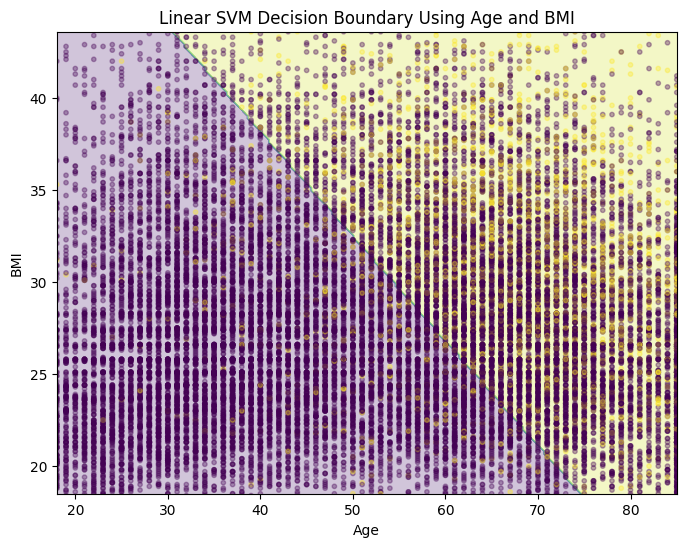

In [62]:
# Linear SVM decision boundary using age and BMI only
# Use only two strong numeric predictors for the visual
visual_features = ["age", "bmi"]

X_visual = df_final[visual_features]
y_visual = df_final["diabetes"]

# Impute missing BMI values
visual_imputer = SimpleImputer(strategy="median")
X_visual_imputed = visual_imputer.fit_transform(X_visual)

# Scale age and BMI before fitting SVM
visual_scaler = StandardScaler()
X_visual_scaled = visual_scaler.fit_transform(X_visual_imputed)

# Fit a linear SVM for visualization
visual_linear_svm = SVC(
    C=best_C_linear,
    kernel="linear",
    class_weight="balanced"
)

visual_linear_svm.fit(X_visual_scaled, y_visual)

# Create grid for decision boundary
x_min, x_max = X_visual_scaled[:, 0].min() - 0.5, X_visual_scaled[:, 0].max() + 0.5
y_min, y_max = X_visual_scaled[:, 1].min() - 0.5, X_visual_scaled[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Predict class over the grid
Z = visual_linear_svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Convert scaled grid values back to original age/BMI units for readable axes
grid_scaled = np.c_[xx.ravel(), yy.ravel()]
grid_original = visual_scaler.inverse_transform(grid_scaled)

xx_original = grid_original[:, 0].reshape(xx.shape)
yy_original = grid_original[:, 1].reshape(yy.shape)

# Plot decision regions
plt.figure(figsize=(8, 6))
plt.contourf(xx_original, yy_original, Z, alpha=0.25)

# Plot actual observations
plt.scatter(
    df_final["age"],
    df_final["bmi"],
    c=df_final["diabetes"],
    alpha=0.35,
    s=10
)

plt.xlabel("Age")
plt.ylabel("BMI")
plt.title("Linear SVM Decision Boundary Using Age and BMI")
plt.xlim(18, 85)
plt.ylim(df_final["bmi"].quantile(0.01), df_final["bmi"].quantile(0.99))

plt.show()

This two variable linear SVM decision boundary shows how age and BMI separate predicted diabetes classifications. The diagonal boundary suggests that respondents with higher age and higher BMI are more likely to fall into the diabetes predicted region while younger respondents with lower BMI are more likely to be classified as non-diabetic. The overlap of points on both sides shows that age and BMI alone do not perfectly separate diabetes status, but they provide a useful visual example of how the linear SVM creates a straight decision boundary. The full model includes additional demographic and health behavior predictors, so this plot should be interpreted as a simplified visualization rather than the complete model.

## Radial SVM

In [63]:
radial_results = []

# Split the existing training data into a smaller training set and validation set
X_tune_train, X_val, y_tune_train, y_val = train_test_split(
    X_train_ready,
    y_train,
    test_size=0.25,
    random_state=42,
    stratify=y_train
)

# Smaller grid to keep runtime reasonable
cost_vals = [0.1, 1, 5]
gamma_vals = [0.001, 0.01, 1]

for c in cost_vals:
    for g in gamma_vals:
        svc = SVC(
            C=c,
            kernel="rbf",
            gamma=g,
            class_weight="balanced",
            cache_size=1000
        )

        # Fit on the smaller tuning-training set
        svc.fit(X_tune_train, y_tune_train)

        # Predict on the validation set
        val_pred = svc.predict(X_val)

        # Balanced accuracy is used because diabetes cases are much less common
        scores = balanced_accuracy_score(y_val, val_pred)

        radial_results.append({
            "C": c,
            "gamma": g,
            "validation_balanced_accuracy": scores,
            "validation_error": 1 - scores
        })

radial_results_df = pd.DataFrame(radial_results).sort_values("validation_error")

display(radial_results_df)

best_C_radial = radial_results_df.iloc[0]["C"]
best_gamma_radial = radial_results_df.iloc[0]["gamma"]

print("Best C for radial SVM:", best_C_radial)
print("Best gamma for radial SVM:", best_gamma_radial)

,C,gamma,validation_balanced_accuracy,validation_error
4,1.0,0.010,0.714768,0.285232
7,5.0,0.010,0.712819,0.287181
6,5.0,0.001,0.710053,0.289947
1,0.1,0.010,0.708551,0.291449
3,1.0,0.001,0.707360,0.292640
0,0.1,0.001,0.705575,0.294425
2,0.1,1.000,0.654788,0.345212
5,1.0,1.000,0.583018,0.416982
8,5.0,1.000,0.550004,0.449996


Best C for radial SVM: 1.0
Best gamma for radial SVM: 0.01


In [64]:
# Fit the final radial SVM using the best C and gamma
svc_radial_best = SVC(
    C=best_C_radial,
    kernel="rbf",
    gamma=best_gamma_radial,
    class_weight="balanced",
    cache_size=1000
)

svc_radial_best.fit(X_train_ready, y_train)

# Predict on training and test sets
train_pred_radial = svc_radial_best.predict(X_train_ready)
test_pred_radial = svc_radial_best.predict(X_test_ready)

# Calculate errors
train_error_radial = np.mean(train_pred_radial != y_train)
test_error_radial = np.mean(test_pred_radial != y_test)

# Calculate balanced accuracy
train_bal_acc_radial = balanced_accuracy_score(y_train, train_pred_radial)
test_bal_acc_radial = balanced_accuracy_score(y_test, test_pred_radial)

print("Best C:", best_C_radial)
print("Best gamma:", best_gamma_radial)
print("Training error:", round(train_error_radial, 4))
print("Test error:", round(test_error_radial, 4))
print("Training balanced accuracy:", round(train_bal_acc_radial, 4))
print("Test balanced accuracy:", round(test_bal_acc_radial, 4))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, test_pred_radial))

print("\nClassification report:")
print(classification_report(y_test, test_pred_radial))

Best C: 1.0
Best gamma: 0.01
Training error: 0.3537
Test error: 0.3486
Training balanced accuracy: 0.7168
Test balanced accuracy: 0.7211

Confusion matrix:
[[3892 2262]
 [ 140  596]]

Classification report:
              precision    recall  f1-score   support

           0       0.97      0.63      0.76      6154
           1       0.21      0.81      0.33       736

    accuracy                           0.65      6890
   macro avg       0.59      0.72      0.55      6890
weighted avg       0.88      0.65      0.72      6890



The tuned radial SVM selected C = 1.0 and gamma = 0.01 with a test balanced accuracy of 0.7211. This is slightly higher than the linear SVM suggesting that a curved decision boundary captured the diabetes classification pattern somewhat better than a straight linear boundary. The model had strong recall for the diabetes class at 0.81 meaning it correctly identified most respondents with diabetes. However precision for the diabetes class remained low at 0.21 so many respondents predicted as diabetic were actually non-diabetic. The radial model improved diabetes detection slightly, but still struggled with false positives.

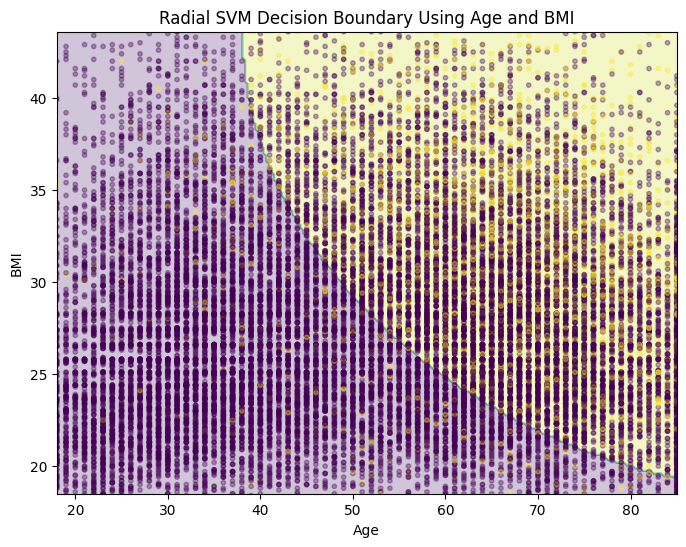

In [65]:
# Radial SVM decision boundary using age and BMI only
# Use two strong numeric predictors for the visual
visual_features = ["age", "bmi"]

X_visual = df_final[visual_features]
y_visual = df_final["diabetes"]

# Impute missing BMI values using the median
visual_imputer = SimpleImputer(strategy="median")
X_visual_imputed = visual_imputer.fit_transform(X_visual)

# Scale predictors before fitting the SVM
visual_scaler = StandardScaler()
X_visual_scaled = visual_scaler.fit_transform(X_visual_imputed)

# Fit radial SVM using the best parameters from the full radial model
visual_radial_svm = SVC(
    C=best_C_radial,
    kernel="rbf",
    gamma=best_gamma_radial,
    class_weight="balanced"
)

visual_radial_svm.fit(X_visual_scaled, y_visual)

# Create a grid of points to show the decision boundary
x_min, x_max = X_visual_scaled[:, 0].min() - 0.5, X_visual_scaled[:, 0].max() + 0.5
y_min, y_max = X_visual_scaled[:, 1].min() - 0.5, X_visual_scaled[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Predict diabetes class over the grid
Z = visual_radial_svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Convert scaled grid values back to original age and BMI units
grid_scaled = np.c_[xx.ravel(), yy.ravel()]
grid_original = visual_scaler.inverse_transform(grid_scaled)

xx_original = grid_original[:, 0].reshape(xx.shape)
yy_original = grid_original[:, 1].reshape(yy.shape)

# Plot decision regions
plt.figure(figsize=(8, 6))
plt.contourf(xx_original, yy_original, Z, alpha=0.25)

# Plot actual observations
plt.scatter(
    df_final["age"],
    df_final["bmi"],
    c=df_final["diabetes"],
    alpha=0.35,
    s=10
)

plt.xlabel("Age")
plt.ylabel("BMI")
plt.title("Radial SVM Decision Boundary Using Age and BMI")

# Limit BMI axis to reduce the effect of extreme values
plt.xlim(18, 85)
plt.ylim(df_final["bmi"].quantile(0.01), df_final["bmi"].quantile(0.99))

plt.show()

## Polynomial SVM

In [66]:
# Tune polynomial SVM using a validation split for time efficiency

poly_results = []

# Split the existing training data into a smaller training set and validation set
X_tune_train, X_val, y_tune_train, y_val = train_test_split(
    X_train_ready,
    y_train,
    test_size=0.25,
    random_state=42,
    stratify=y_train
)

# Keep grid small because polynomial SVMs can be slow
cost_vals = [0.1, 1, 5]
degree_vals = [1, 2, 3]
coef_vals = [1, 2, 3]

for c in cost_vals:
    for d in degree_vals:
        for r in coef_vals:
            svc = SVC(
                C=c,
                kernel="poly",
                degree=d,
                coef0=r,
                gamma="scale",
                class_weight="balanced",
                cache_size=1000
            )

            # Fit on the smaller tuning-training set
            svc.fit(X_tune_train, y_tune_train)

            # Predict on the validation set
            val_pred = svc.predict(X_val)

            # Balanced accuracy is used because diabetes cases are much less common
            scores = balanced_accuracy_score(y_val, val_pred)

            poly_results.append({
                "C": c,
                "degree": d,
                "coef0": r,
                "validation_balanced_accuracy": scores,
                "validation_error": 1 - scores
            })

poly_results_df = pd.DataFrame(poly_results).sort_values("validation_error")

display(poly_results_df)

best_C_poly = poly_results_df.iloc[0]["C"]
best_degree_poly = poly_results_df.iloc[0]["degree"]
best_coef0_poly = poly_results_df.iloc[0]["coef0"]

print("Best C for polynomial SVM:", best_C_poly)
print("Best degree for polynomial SVM:", best_degree_poly)
print("Best coef0 for polynomial SVM:", best_coef0_poly)

,C,degree,coef0,validation_balanced_accuracy,validation_error
13,1.0,2,2,0.715285,0.284715
14,1.0,2,3,0.715285,0.284715
12,1.0,2,1,0.715177,0.284823
4,0.1,2,2,0.711196,0.288804
5,0.1,2,3,0.711047,0.288953
3,0.1,2,1,0.710830,0.289170
7,0.1,3,2,0.708618,0.291382
6,0.1,3,1,0.708578,0.291422
23,5.0,2,3,0.708568,0.291432
21,5.0,2,1,0.708568,0.291432


Best C for polynomial SVM: 1.0
Best degree for polynomial SVM: 2.0
Best coef0 for polynomial SVM: 2.0


In [67]:
# Fit the final polynomial SVM using the best C, degree, and coef0
svc_poly_best = SVC(
    C=float(best_C_poly),
    kernel="poly",
    degree=int(best_degree_poly),
    coef0=float(best_coef0_poly),
    gamma="scale",
    class_weight="balanced",
    cache_size=1000
)

svc_poly_best.fit(X_train_ready, y_train)

# Predict on training and test sets
train_pred_poly = svc_poly_best.predict(X_train_ready)
test_pred_poly = svc_poly_best.predict(X_test_ready)

# Calculate errors
train_error_poly = np.mean(train_pred_poly != y_train)
test_error_poly = np.mean(test_pred_poly != y_test)

# Calculate balanced accuracy
train_bal_acc_poly = balanced_accuracy_score(y_train, train_pred_poly)
test_bal_acc_poly = balanced_accuracy_score(y_test, test_pred_poly)

print("Best C:", best_C_poly)
print("Best degree:", int(best_degree_poly))
print("Best coef0:", best_coef0_poly)
print("Training error:", round(train_error_poly, 4))
print("Test error:", round(test_error_poly, 4))
print("Training balanced accuracy:", round(train_bal_acc_poly, 4))
print("Test balanced accuracy:", round(test_bal_acc_poly, 4))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, test_pred_poly))

print("\nClassification report:")
print(classification_report(y_test, test_pred_poly))

Best C: 1.0
Best degree: 2
Best coef0: 2.0
Training error: 0.3718
Test error: 0.3649
Training balanced accuracy: 0.7169
Test balanced accuracy: 0.7156

Confusion matrix:
[[3774 2380]
 [ 134  602]]

Classification report:
              precision    recall  f1-score   support

           0       0.97      0.61      0.75      6154
           1       0.20      0.82      0.32       736

    accuracy                           0.64      6890
   macro avg       0.58      0.72      0.54      6890
weighted avg       0.88      0.64      0.70      6890



The tuned polynomial SVM selected C = 1.0, degree = 2, and coef0 = 2.0, producing a test balanced accuracy of 0.7156. This was slightly better than the linear SVM but slightly worse than the radial SVM. The polynomial model had strong recall for the diabetes class at 0.82, meaning it correctly detected many respondents with diabetes. However, its diabetes precision was low at 0.20, so it also produced many false positives. Overall, the polynomial kernel captured some nonlinear structure in the data, but it did not outperform the radial model.

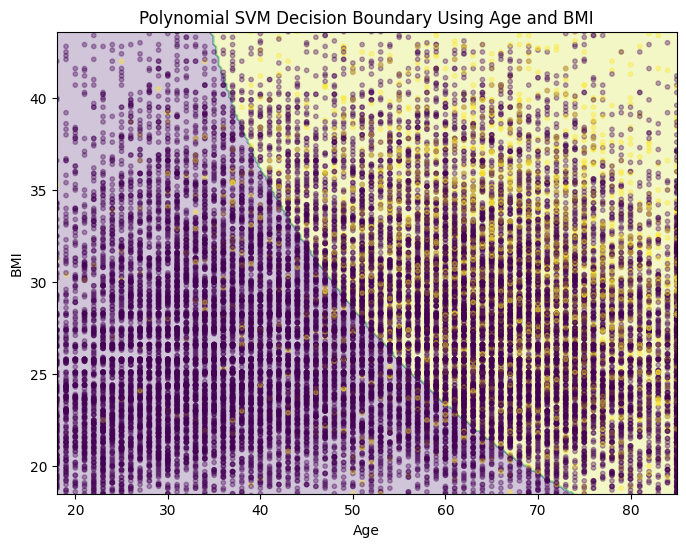

In [68]:
# Polynomial SVM decision boundary using age and BMI only
visual_features = ["age", "bmi"]

X_visual = df_final[visual_features]
y_visual = df_final["diabetes"]

# Impute missing BMI values using the median
visual_imputer = SimpleImputer(strategy="median")
X_visual_imputed = visual_imputer.fit_transform(X_visual)

# Scale predictors before fitting the SVM
visual_scaler = StandardScaler()
X_visual_scaled = visual_scaler.fit_transform(X_visual_imputed)

# Fit polynomial SVM using the best parameters from the full polynomial model
visual_poly_svm = SVC(
    C=best_C_poly,
    kernel="poly",
    degree=int(best_degree_poly),
    coef0=best_coef0_poly,
    gamma="scale",
    class_weight="balanced"
)

visual_poly_svm.fit(X_visual_scaled, y_visual)

# Create a grid of points to show the decision boundary
x_min, x_max = X_visual_scaled[:, 0].min() - 0.5, X_visual_scaled[:, 0].max() + 0.5
y_min, y_max = X_visual_scaled[:, 1].min() - 0.5, X_visual_scaled[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Predict diabetes class over the grid
Z = visual_poly_svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Convert scaled grid values back to original age and BMI units
grid_scaled = np.c_[xx.ravel(), yy.ravel()]
grid_original = visual_scaler.inverse_transform(grid_scaled)

xx_original = grid_original[:, 0].reshape(xx.shape)
yy_original = grid_original[:, 1].reshape(yy.shape)

# Plot decision regions
plt.figure(figsize=(8, 6))
plt.contourf(xx_original, yy_original, Z, alpha=0.25)

# Plot actual observations
plt.scatter(
    df_final["age"],
    df_final["bmi"],
    c=df_final["diabetes"],
    alpha=0.35,
    s=10
)

plt.xlabel("Age")
plt.ylabel("BMI")
plt.title("Polynomial SVM Decision Boundary Using Age and BMI")

# Limit BMI axis to reduce the effect of extreme values
plt.xlim(18, 85)
plt.ylim(df_final["bmi"].quantile(0.01), df_final["bmi"].quantile(0.99))

plt.show()

The polynomial SVM shows a slightly curved decision boundary using age and BMI. Older respondents with higher BMI are more likely to be classified as diabetic, while younger respondents with lower BMI are more likely to be classified as non-diabetic. The heavy overlap shows that age and BMI alone do not fully separate diabetes status.

# Model Comparisons

In [69]:
# Compare model performance using metrics appropriate for imbalanced classes
comparison_results = pd.DataFrame([
    {
        "model": "Linear SVM",
        "best_parameters": f"C = {best_C_linear}",
        "accuracy": accuracy_score(y_test, test_pred_linear),
        "balanced_accuracy": balanced_accuracy_score(y_test, test_pred_linear),
        "diabetes_precision": precision_score(y_test, test_pred_linear, pos_label=1),
        "diabetes_recall": recall_score(y_test, test_pred_linear, pos_label=1),
        "diabetes_f1": f1_score(y_test, test_pred_linear, pos_label=1),
        "test_error": test_error_linear
    },
    {
        "model": "Radial SVM",
        "best_parameters": f"C = {best_C_radial}, gamma = {best_gamma_radial}",
        "accuracy": accuracy_score(y_test, test_pred_radial),
        "balanced_accuracy": balanced_accuracy_score(y_test, test_pred_radial),
        "diabetes_precision": precision_score(y_test, test_pred_radial, pos_label=1),
        "diabetes_recall": recall_score(y_test, test_pred_radial, pos_label=1),
        "diabetes_f1": f1_score(y_test, test_pred_radial, pos_label=1),
        "test_error": test_error_radial
    },
    {
        "model": "Polynomial SVM",
        "best_parameters": f"C = {best_C_poly}, degree = {best_degree_poly}, coef0 = {best_coef0_poly}",
        "accuracy": accuracy_score(y_test, test_pred_poly),
        "balanced_accuracy": balanced_accuracy_score(y_test, test_pred_poly),
        "diabetes_precision": precision_score(y_test, test_pred_poly, pos_label=1),
        "diabetes_recall": recall_score(y_test, test_pred_poly, pos_label=1),
        "diabetes_f1": f1_score(y_test, test_pred_poly, pos_label=1),
        "test_error": test_error_poly
    }
])

comparison_results = comparison_results.round(4)

display(comparison_results)

,model,best_parameters,accuracy,balanced_accuracy,diabetes_precision,diabetes_recall,diabetes_f1,test_error
0,Linear SVM,C = 5.0,0.6595,0.7095,0.2071,0.7731,0.3266,0.3405
1,Radial SVM,"C = 1.0, gamma = 0.01",0.6514,0.7211,0.2085,0.8098,0.3317,0.3486
2,Polynomial SVM,"C = 1.0, degree = 2.0, coef0 = 2.0",0.6351,0.7156,0.2019,0.8179,0.3238,0.3649


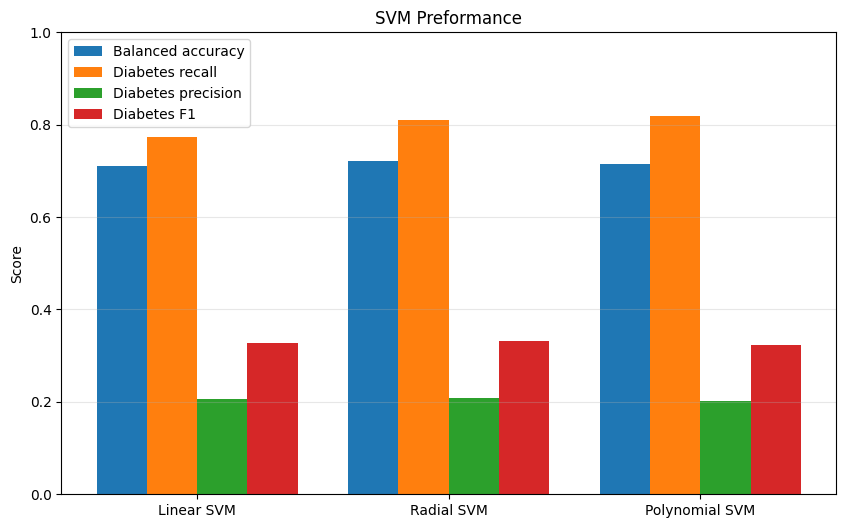

In [76]:
# Model comparison bar chart
# Visual compares the three SVM models using metrics that matter for class imbalance

# Select the most important metrics for comparison
plot_metrics = [
    "balanced_accuracy",
    "diabetes_recall",
    "diabetes_precision",
    "diabetes_f1"
]

# Make a plotting version of the comparison table
plot_df = comparison_results[["model"] + plot_metrics].copy()

# Set up grouped bar chart positions
models = plot_df["model"]
x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(10, 6))

plt.bar(x - 1.5*width, plot_df["balanced_accuracy"], width, label="Balanced accuracy")
plt.bar(x - 0.5*width, plot_df["diabetes_recall"], width, label="Diabetes recall")
plt.bar(x + 0.5*width, plot_df["diabetes_precision"], width, label="Diabetes precision")
plt.bar(x + 1.5*width, plot_df["diabetes_f1"], width, label="Diabetes F1")

plt.xticks(x, models)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("SVM Preformance")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

The comparison table and bar chart show that the three SVM models performed similarly but the radial SVM was the strongest overall. It had the highest balanced accuracy at 0.7211 and the highest diabetes F1-score at 0.3317 making it the best balance between detecting diabetes cases and avoiding false positives. The polynomial SVM had the highest diabetes recall at 0.8179 meaning it identified the most diabetes cases but it also had the lowest precision and highest test error. The radial SVM is the preferred model because it provides the best overall tradeoff for this imbalanced classification task.

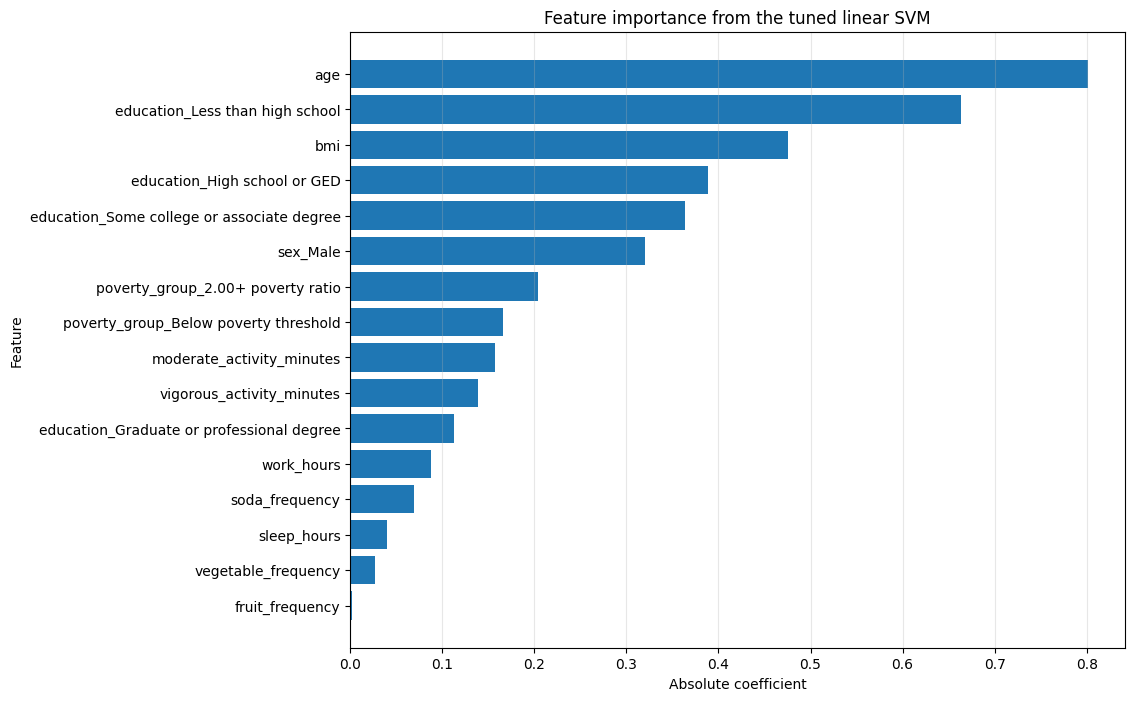

In [71]:
# Feature importance from the tuned linear SVM
linear_feature_importance = pd.DataFrame({
    "feature": X_train_ready.columns,
    "coefficient": svc_linear_best.coef_[0]
})

linear_feature_importance["importance"] = linear_feature_importance["coefficient"].abs()

linear_feature_importance = linear_feature_importance.sort_values(
    "importance",
    ascending=True
)

plt.figure(figsize=(10, 8))

plt.barh(
    linear_feature_importance["feature"],
    linear_feature_importance["importance"]
)

plt.xlabel("Absolute coefficient")
plt.ylabel("Feature")
plt.title("Feature importance from the tuned linear SVM")

plt.grid(axis="x", alpha=0.3)
plt.show()

Feature importance is shown for the tuned linear SVM using absolute coefficient size. Age, education, and BMI contributed most strongly to the linear decision boundary. Radial and polynomial SVMs were not shown in this feature importance chart because nonlinear kernels do not provide directly interpretable feature coefficients.

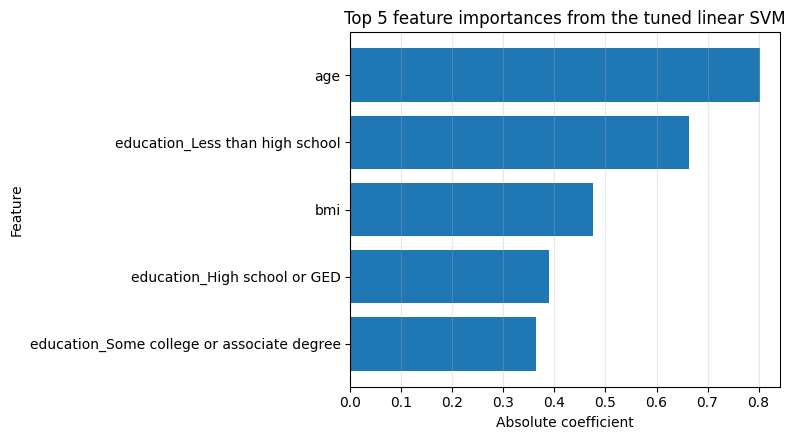

In [77]:
# Top 5 feature importances from the tuned linear SVM
top5_linear_importance = linear_feature_importance.sort_values(
    "importance",
    ascending=False
).head(5)

# Sort ascending so the largest bar appears at the top after invert_yaxis()
top5_linear_importance = top5_linear_importance.sort_values(
    "importance",
    ascending=True
)

plt.figure(figsize=(8, 4.5))

plt.barh(
    top5_linear_importance["feature"],
    top5_linear_importance["importance"]
)

plt.xlabel("Absolute coefficient")
plt.ylabel("Feature")
plt.title("Top 5 feature importances from the tuned linear SVM")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Further Investigation of Features

In [72]:
# Explore relationship between education and poverty group
education_poverty_table = pd.crosstab(
    df_final["education"],
    df_final["poverty_group"],
    normalize="index"
).round(3)

display(education_poverty_table)

poverty_group,1.00 to 1.99 poverty ratio,2.00+ poverty ratio,Below poverty threshold
education,,,
Bachelor's degree,0.083,0.883,0.034
Graduate or professional degree,0.041,0.940,0.019
High school or GED,0.266,0.592,0.142
Less than high school,0.349,0.340,0.311
Some college or associate degree,0.185,0.720,0.094


In [73]:
# Diabetes rate by poverty group
diabetes_by_poverty = (
    df_final
    .groupby("poverty_group")["diabetes"]
    .agg(["count", "mean"])
    .rename(columns={"count": "n", "mean": "diabetes_rate"})
    .sort_values("diabetes_rate", ascending=False)
)

diabetes_by_poverty["diabetes_rate"] = diabetes_by_poverty["diabetes_rate"].round(3)

display(diabetes_by_poverty)

,n,diabetes_rate
poverty_group,,
Below poverty threshold,2771,0.153
1.00 to 1.99 poverty ratio,4825,0.141
2.00+ poverty ratio,19962,0.092


In [74]:
# Diabetes rate by education and poverty group together
education_poverty_diabetes = pd.pivot_table(
    df_final,
    values="diabetes",
    index="education",
    columns="poverty_group",
    aggfunc="mean"
).round(3)

display(education_poverty_diabetes)

poverty_group,1.00 to 1.99 poverty ratio,2.00+ poverty ratio,Below poverty threshold
education,,,
Bachelor's degree,0.083,0.062,0.074
Graduate or professional degree,0.089,0.070,0.128
High school or GED,0.141,0.120,0.160
Less than high school,0.208,0.158,0.177
Some college or associate degree,0.129,0.106,0.148


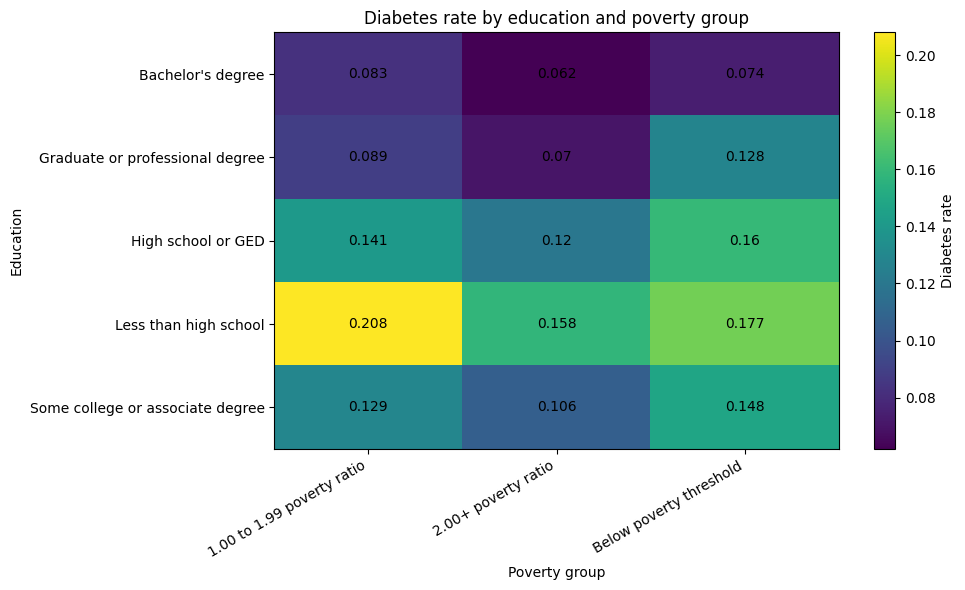

In [75]:
# Heatmap of diabetes rate by education and poverty group
plt.figure(figsize=(10, 6))

plt.imshow(education_poverty_diabetes, aspect="auto")

plt.xticks(
    ticks=np.arange(len(education_poverty_diabetes.columns)),
    labels=education_poverty_diabetes.columns,
    rotation=30,
    ha="right"
)

plt.yticks(
    ticks=np.arange(len(education_poverty_diabetes.index)),
    labels=education_poverty_diabetes.index
)

plt.colorbar(label="Diabetes rate")
plt.title("Diabetes rate by education and poverty group")
plt.xlabel("Poverty group")
plt.ylabel("Education")

# Add values inside cells
for i in range(education_poverty_diabetes.shape[0]):
    for j in range(education_poverty_diabetes.shape[1]):
        value = education_poverty_diabetes.iloc[i, j]
        if not pd.isna(value):
            plt.text(j, i, value, ha="center", va="center")

plt.tight_layout()
plt.show()

I noticed in the feature importance that less than high school education was a much higher predictor than lower poverty levels. I assumed they would be around the same as they likely map out similar relationships in the data. Lower education, lower paying job or unemployment, which leads to a lower quality diet generally speaking.

These results help explain why education appeared more important than poverty in the linear SVM. Diabetes rates do increase as poverty worsens, from 9.2% in the 2.00+ poverty group to 15.3% below the poverty threshold. However, education shows a stronger and more consistent pattern within each poverty group. Respondents with less than a high school education had the highest diabetes rates across all poverty categories, including 20.8% in the 1.00 to 1.99 poverty ratio group and 17.7% below the poverty threshold. By comparison, bachelor's degree respondents stayed much lower between 6.2% and 8.3%.

This suggests that education is not just acting as a proxy for poverty. It may capture additional factors such as health literacy, occupation type, long term access to resources, or differences in preventive care. That helps explain why education had a stronger coefficient than poverty in the linear SVM.